# Workforce Attrition & Hiring Demand Forecast

## Business Objective
The goal of this project is to identify employee groups with high attrition risk and translate that risk into estimated replacement hiring demand. This helps a Talent Acquisition team understand which departments and roles may require future recruiting attention.

## Key Questions
- Which departments are at higher attrition risk?
- Which employee groups are more likely to leave?
- Where may replacement hiring demand increase?
- Which functions should recruiting prioritize first?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

Load the dataset

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Inspect the dataset structure

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   obje

Check the target variable

In [4]:
print(df["Attrition"].value_counts())
print("\nAttrition rate:")
print(df["Attrition"].value_counts(normalize=True))

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate:
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


Decide what to keep, what to drop, and why

In [5]:
drop_cols = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df = df.drop(columns=drop_cols)

print("New shape:", df.shape)
print(df.columns.tolist())

New shape: (1470, 31)
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Create the target flag

In [6]:
df["Attrition_Flag"] = df["Attrition"].map({"Yes": 1, "No": 0})

print(df[["Attrition", "Attrition_Flag"]].head())
print(df["Attrition_Flag"].value_counts())

  Attrition  Attrition_Flag
0       Yes               1
1        No               0
2       Yes               1
3        No               0
4        No               0
Attrition_Flag
0    1233
1     237
Name: count, dtype: int64


Attrition rate by Department

Department
Sales                     0.206278
Human Resources           0.190476
Research & Development    0.138398
Name: Attrition_Flag, dtype: float64


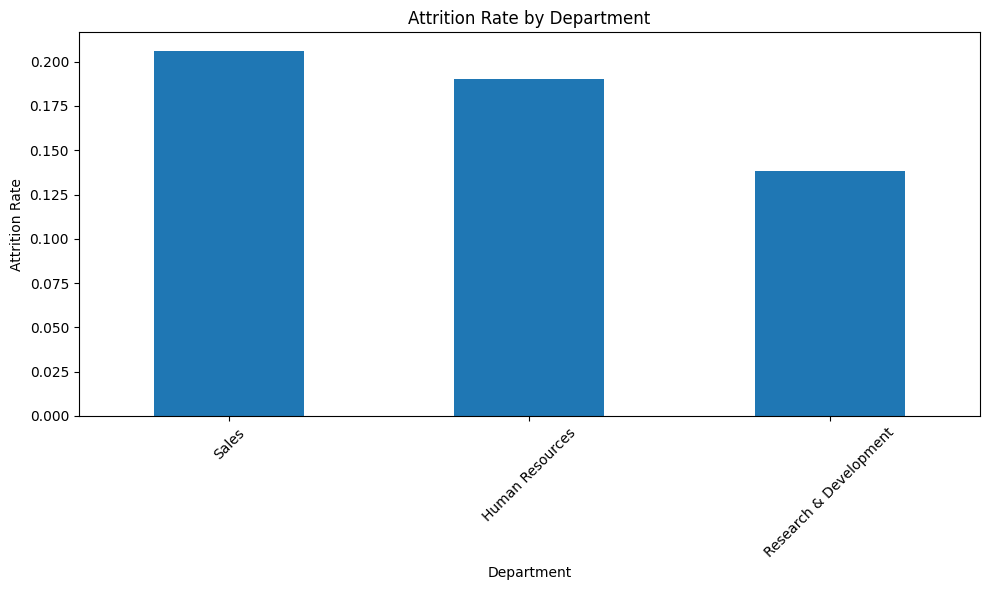

In [7]:
dept_attrition = (
    df.groupby("Department")["Attrition_Flag"]
    .mean()
    .sort_values(ascending=False)
)

print(dept_attrition)

dept_attrition.plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate")
plt.xlabel("Department")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Attrition rate by OverTime

OverTime
Yes    0.305288
No     0.104364
Name: Attrition_Flag, dtype: float64


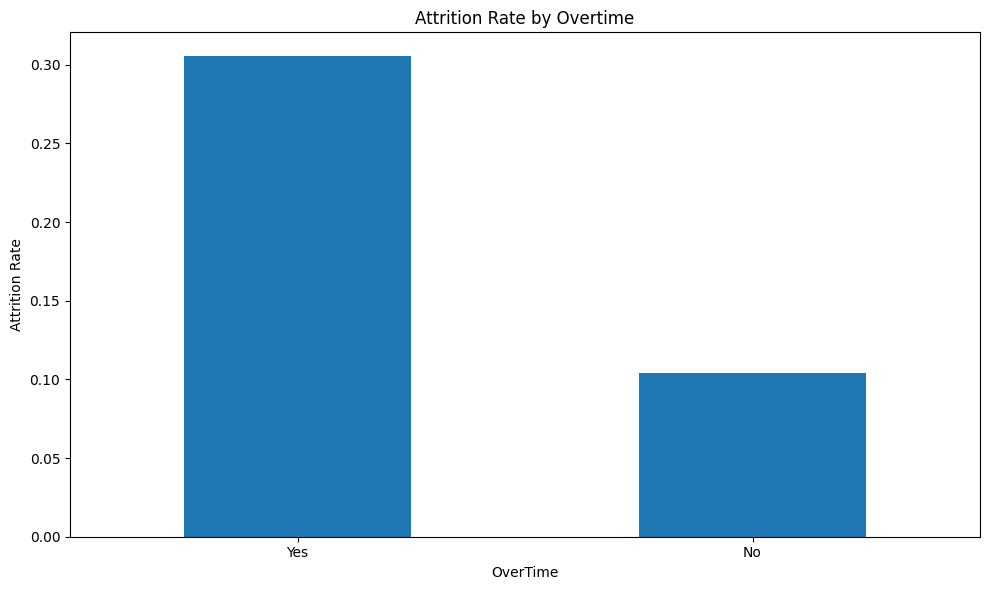

In [8]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition_Flag"]
    .mean()
    .sort_values(ascending=False)
)

print(overtime_attrition)

overtime_attrition.plot(kind="bar")
plt.title("Attrition Rate by Overtime")
plt.ylabel("Attrition Rate")
plt.xlabel("OverTime")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Attrition rate by Job Role

JobRole
Sales Representative         0.397590
Laboratory Technician        0.239382
Human Resources              0.230769
Sales Executive              0.174847
Research Scientist           0.160959
Manufacturing Director       0.068966
Healthcare Representative    0.068702
Manager                      0.049020
Research Director            0.025000
Name: Attrition_Flag, dtype: float64


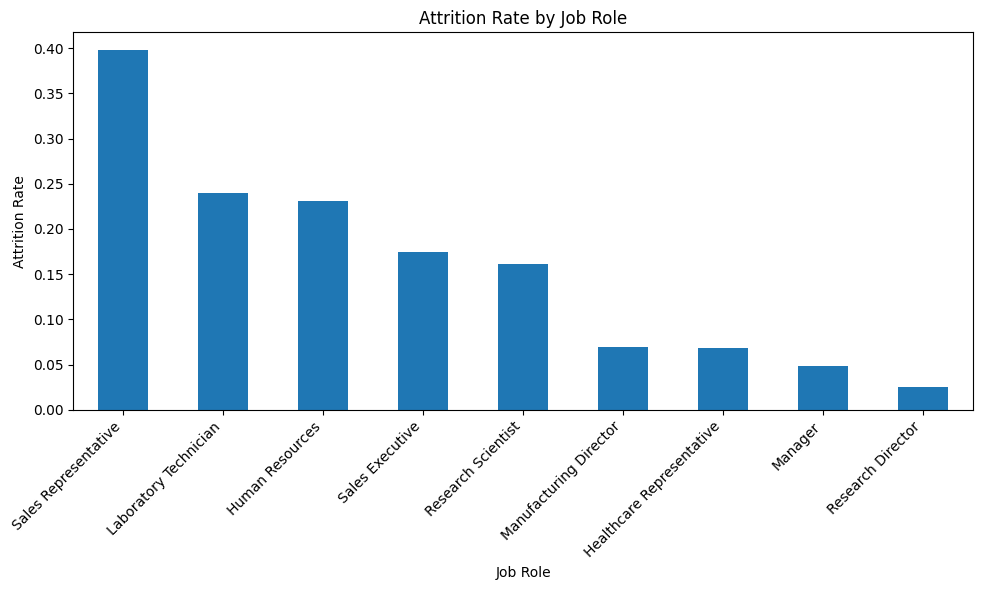

In [9]:
role_attrition = (
    df.groupby("JobRole")["Attrition_Flag"]
    .mean()
    .sort_values(ascending=False)
)

print(role_attrition)

role_attrition.plot(kind="bar")
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate")
plt.xlabel("Job Role")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Explore likely attrition drivers

JobSatisfaction
Low          0.228374
Medium       0.164286
High         0.165158
Very High    0.113290
Name: Attrition_Flag, dtype: float64


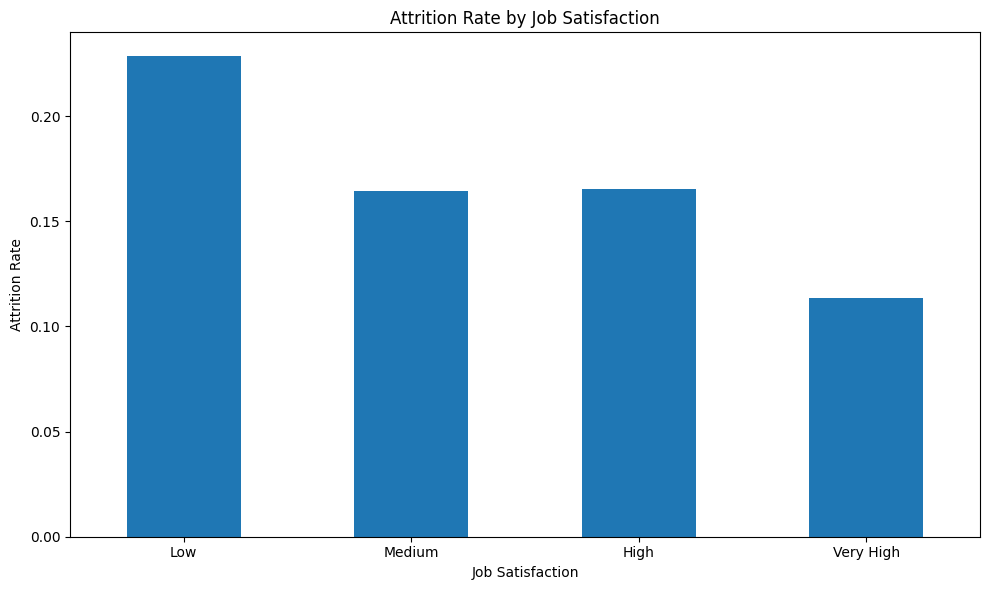

In [15]:
job_sat_map = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

job_sat_attrition = (
    df.groupby("JobSatisfaction")["Attrition_Flag"]
    .mean()
    .rename(index=job_sat_map)
)

print(job_sat_attrition)

job_sat_attrition.plot(kind="bar")
plt.title("Attrition Rate by Job Satisfaction")
plt.ylabel("Attrition Rate")
plt.xlabel("Job Satisfaction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Attrition rate by WorkLifeBalance

Average YearsAtCompany by Attrition

WorkLifeBalance
Bad       0.312500
Good      0.168605
Better    0.142217
Best      0.176471
Name: Attrition_Flag, dtype: float64


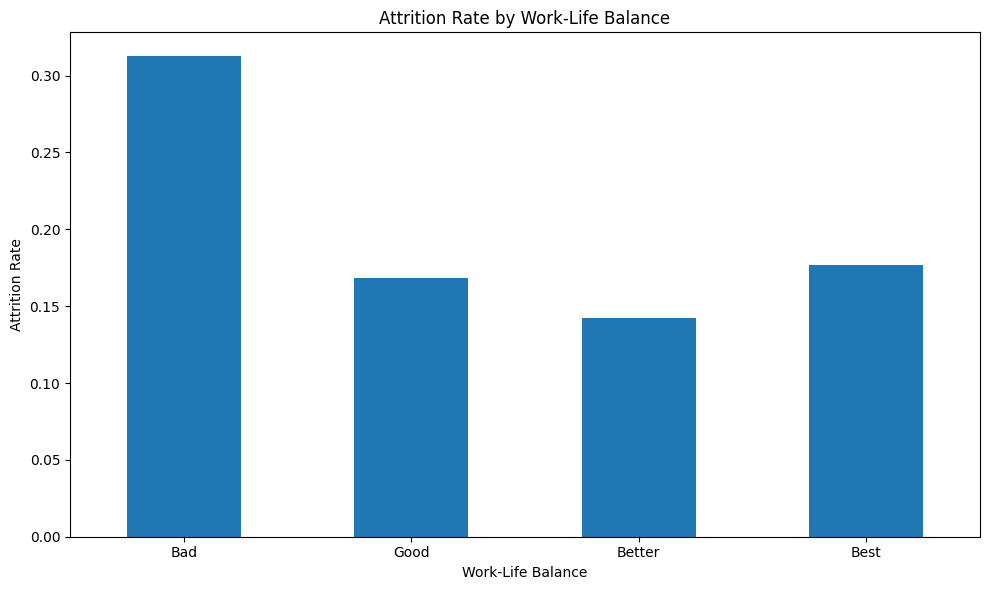

In [16]:
wlb_map = {
    1: "Bad",
    2: "Good",
    3: "Better",
    4: "Best"
}

wlb_attrition = (
    df.groupby("WorkLifeBalance")["Attrition_Flag"]
    .mean()
    .rename(index=wlb_map)
)

print(wlb_attrition)

wlb_attrition.plot(kind="bar")
plt.title("Attrition Rate by Work-Life Balance")
plt.ylabel("Attrition Rate")
plt.xlabel("Work-Life Balance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64


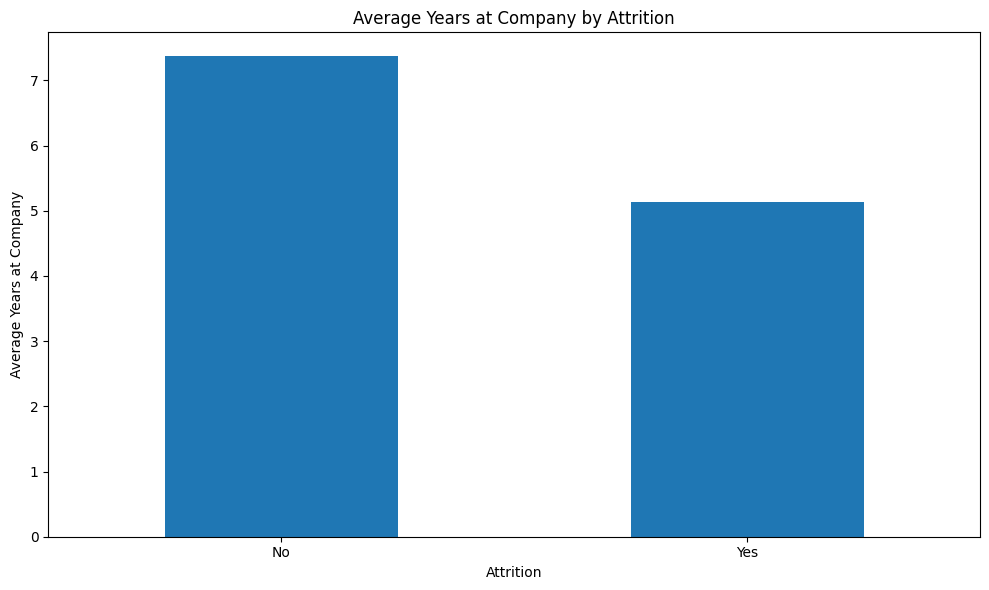

In [13]:
years_attrition = df.groupby("Attrition")["YearsAtCompany"].mean()

print(years_attrition)

years_attrition.plot(kind="bar")
plt.title("Average Years at Company by Attrition")
plt.ylabel("Average Years at Company")
plt.xlabel("Attrition")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Define the model input and target

In [17]:
X = df.drop(columns=["Attrition", "Attrition_Flag"])
y = df["Attrition_Flag"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 30)
y shape: (1470,)


Define the model input and target

In [18]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


## Data Preprocessing Pipeline

Before training machine learning models, we must prepare the data.

Two types of preprocessing will be applied:

### Numeric Features
- Missing values will be replaced using the **median**
- Features will be **standardized** to ensure comparable scales

### Categorical Features
- Missing values will be filled using the **most frequent category**
- Variables will be converted into numerical format using **One-Hot Encoding**

To handle these transformations efficiently, we use a **ColumnTransformer pipeline** from Scikit-Learn.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

..

In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'DailyRate', 'DistanceFromHome',
                                  'Education', 'EnvironmentSatisfaction',
                                  'HourlyRate', 'JobInvolvement', 'JobLevel',
                                  'JobSatisfaction', 'MonthlyIncome',
                                  'MonthlyRate', 'NumCompaniesWorked',
                                  'PercentSalaryHike', 'PerformanceRa...
                                  'TrainingTimesLastYear', 'WorkLifeBalance',
                                  'YearsAtCompany', 'YearsInCurrentRole',
                                  'YearsSinceLastPromotion',
                                  'YearsWithCurrManager']),
                    

## Train-Test Split

To properly evaluate model performance, the dataset is divided into:

- **Training Set (80%)** → used to train the model
- **Test Set (20%)** → used to evaluate model performance on unseen data

We use **stratified sampling** to ensure that the attrition ratio remains consistent in both sets.

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train mean:", y_train.mean())
print("y_test mean:", y_test.mean())

X_train shape: (1176, 30)
X_test shape: (294, 30)
y_train mean: 0.16156462585034015
y_test mean: 0.1598639455782313


## Baseline Model: Logistic Regression

The first model used in this project is **Logistic Regression**.

This is a common baseline model for binary classification problems such as attrition prediction, where the target has two possible outcomes:

- **1 = Attrition**
- **0 = No Attrition**

Logistic Regression is useful because it is:
- easy to interpret
- computationally efficient
- a strong benchmark for classification tasks

The model will be trained using the preprocessing pipeline defined earlier, so both numerical and categorical variables are handled automatically.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [24]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [25]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

## Logistic Regression Evaluation

To evaluate the baseline model, we use several classification metrics:

- **Accuracy** → overall proportion of correct predictions
- **Precision** → how many predicted attrition cases were actually attrition
- **Recall** → how many real attrition cases were successfully identified
- **F1 Score** → balance between precision and recall
- **ROC-AUC** → how well the model separates attrition vs non-attrition cases

Because attrition is an imbalanced target, **recall and ROC-AUC** are especially important.

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8605442176870748
Precision: 0.6153846153846154
Recall: 0.3404255319148936
F1 Score: 0.4383561643835616
ROC-AUC: 0.8115255405289


In [27]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

Confusion Matrix:

[[237  10]
 [ 31  16]]


## Second Model: Random Forest Classifier

After establishing a Logistic Regression baseline, the next step is to test a more flexible model.

A **Random Forest Classifier** is used because it can:

- capture nonlinear relationships in the data
- handle interactions between variables
- improve predictive performance on structured HR datasets

This is especially useful in attrition analysis, where employee exits may depend on multiple combined factors such as overtime, job role, tenure, and satisfaction.

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [31]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

## Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as the baseline model:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The main goal is to see whether the model improves recall and overall identification of employees at risk of attrition.

In [32]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.8469387755102041
Precision: 0.625
Recall: 0.10638297872340426
F1 Score: 0.18181818181818182
ROC-AUC: 0.7831854595572402


In [33]:
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294

Confusion Matrix:

[[244   3]
 [ 42   5]]


## Threshold Tuning for Workforce Planning

By default, classification models use a probability threshold of *0.50* to assign classes.

However, for workforce planning and attrition risk detection, missing true attrition cases can be more costly than generating a few extra false positives.

To improve identification of at-risk employees, we test a lower decision threshold. This may reduce precision slightly, but it can improve *recall*, which is important for estimating replacement hiring demand.

In [37]:
threshold = 0.30
y_pred_30 = (y_prob >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_30))
print("Precision:", precision_score(y_test, y_pred_30))
print("Recall:", recall_score(y_test, y_pred_30))
print("F1 Score:", f1_score(y_test, y_pred_30))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_30))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_30))

Accuracy: 0.8401360544217688
Precision: 0.5
Recall: 0.5106382978723404
F1 Score: 0.5052631578947369
ROC-AUC: 0.8115255405289

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.90      0.90       247
           1       0.50      0.51      0.51        47

    accuracy                           0.84       294
   macro avg       0.70      0.71      0.70       294
weighted avg       0.84      0.84      0.84       294

Confusion Matrix:

[[223  24]
 [ 23  24]]


## Predict Attrition Risk for Workforce Planning

After selecting the Logistic Regression model and adjusting the probability threshold, the next step is to generate attrition risk predictions for the full employee population.

This allows us to translate model output into a workforce planning view by estimating:

- predicted attrition risk by employee
- expected leavers by department
- likely replacement hiring demand by function

This step makes the model directly useful for Talent Acquisition planning.

In [39]:
df["Predicted_Attrition_Prob"] = log_model.predict_proba(X)[:, 1]
df["Predicted_Attrition_Flag_30"] = (df["Predicted_Attrition_Prob"] >= 0.30).astype(int)

df[["Department", "JobRole", "Predicted_Attrition_Prob", "Predicted_Attrition_Flag_30"]].head()

,Department,JobRole,Predicted_Attrition_Prob,Predicted_Attrition_Flag_30
0,Sales,Sales Executive,0.724400,1
1,Research & Development,Research Scientist,0.014683,0
2,Research & Development,Laboratory Technician,0.483896,1
3,Research & Development,Research Scientist,0.104140,0
4,Research & Development,Laboratory Technician,0.413371,1


## Estimated Replacement Hiring Demand by Department

To support Talent Acquisition planning, predicted attrition is aggregated by department.

For each department, we calculate:

- total headcount
- predicted leavers
- average attrition risk
- estimated backfill rate

These metrics help identify which departments may require greater recruiting attention.

In [40]:
dept_hiring_need = (
    df.groupby("Department")
    .agg(
        Headcount=("Attrition_Flag", "count"),
        Predicted_Leavers=("Predicted_Attrition_Flag_30", "sum"),
        Avg_Attrition_Risk=("Predicted_Attrition_Prob", "mean")
    )
    .sort_values("Predicted_Leavers", ascending=False)
)

dept_hiring_need["Estimated_Backfill_Rate"] = (
    dept_hiring_need["Predicted_Leavers"] / dept_hiring_need["Headcount"]
)

dept_hiring_need

,Headcount,Predicted_Leavers,Avg_Attrition_Risk,Estimated_Backfill_Rate
Department,,,,
Research & Development,961,146,0.132659,0.151925
Sales,446,108,0.212007,0.242152
Human Resources,63,11,0.190980,0.174603


## Predicted Replacement Hiring Demand by Department

The chart below shows the estimated number of employees at risk of attrition in each department based on the tuned Logistic Regression model.

This provides a simple proxy for future replacement hiring demand.

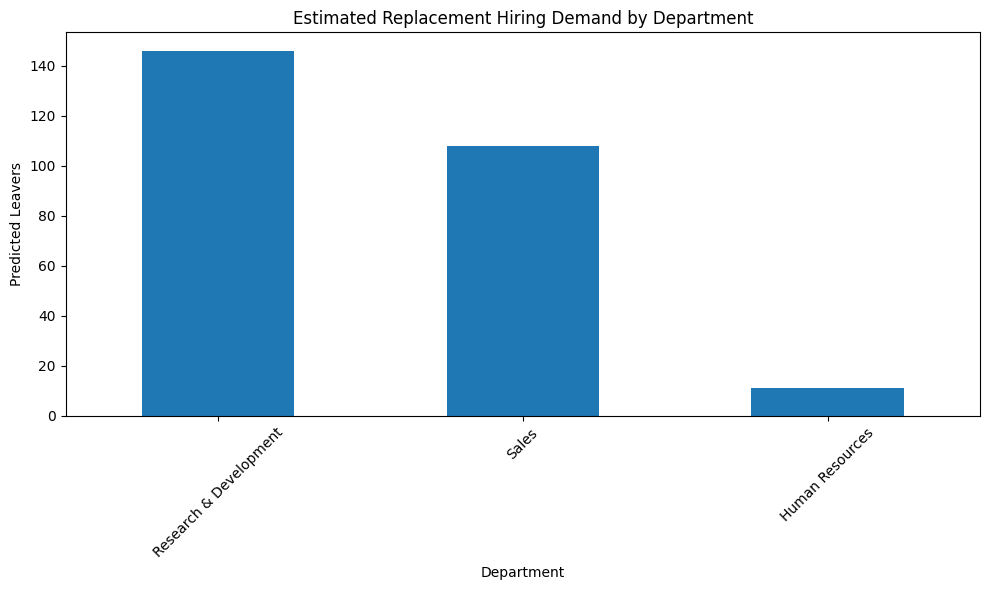

In [41]:
dept_hiring_need["Predicted_Leavers"].plot(kind="bar")
plt.title("Estimated Replacement Hiring Demand by Department")
plt.ylabel("Predicted Leavers")
plt.xlabel("Department")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Department-Level Workforce Planning Insight

The model suggests that *Research & Development* may generate the highest absolute replacement hiring demand due to its larger workforce size, with an estimated *146 predicted leavers*.

However, *Sales* shows the highest relative replacement pressure, with an estimated *24.2% backfill rate, compared with **15.2%* in Research & Development.

This suggests that Talent Acquisition should balance two priorities:
- *R&D* for higher total backfill volume
- *Sales* for higher attrition intensity and replacement urgency

## Estimated Replacement Hiring Demand by Job Role

Department-level analysis is useful for broad workforce planning, but job-role analysis provides a more actionable view for Talent Acquisition teams.

In this step, predicted attrition is aggregated by job role to identify which specific positions may require the greatest replacement hiring effort.

In [42]:
role_hiring_need = (
    df.groupby("JobRole")
    .agg(
        Headcount=("Attrition_Flag", "count"),
        Predicted_Leavers=("Predicted_Attrition_Flag_30", "sum"),
        Avg_Attrition_Risk=("Predicted_Attrition_Prob", "mean")
    )
    .sort_values("Predicted_Leavers", ascending=False)
)

role_hiring_need["Estimated_Backfill_Rate"] = (
    role_hiring_need["Predicted_Leavers"] / role_hiring_need["Headcount"]
)

role_hiring_need

,Headcount,Predicted_Leavers,Avg_Attrition_Risk,Estimated_Backfill_Rate
JobRole,,,,
Laboratory Technician,259,87,0.248908,0.335907
Sales Executive,326,63,0.178313,0.193252
Research Scientist,292,46,0.137457,0.157534
Sales Representative,83,44,0.405946,0.530120
Human Resources,52,11,0.220613,0.211538
Healthcare Representative,131,5,0.062122,0.038168
Manufacturing Director,145,5,0.067656,0.034483
Manager,102,2,0.057777,0.019608
Research Director,80,2,0.029132,0.025000


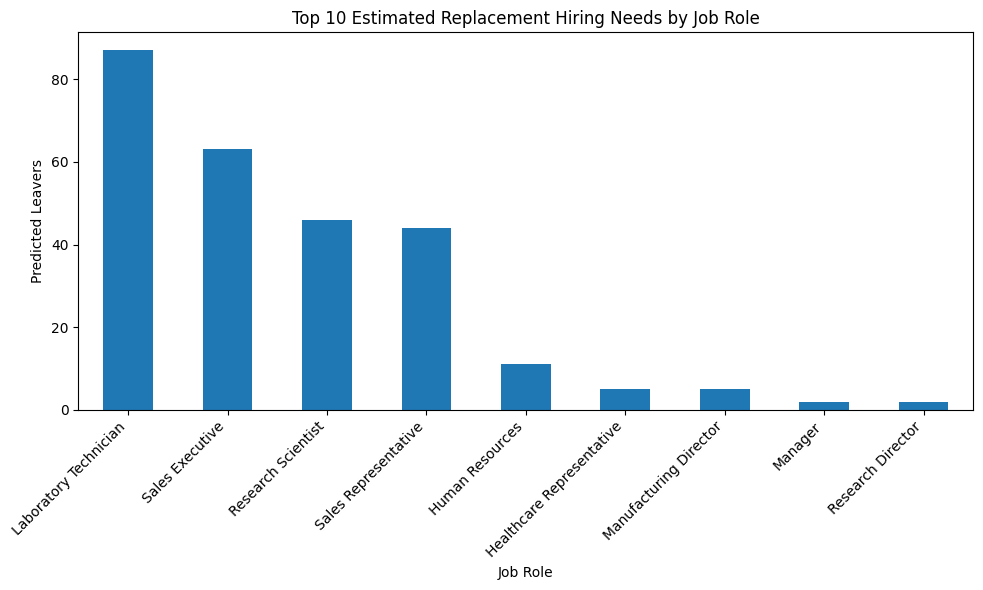

In [43]:
role_hiring_need["Predicted_Leavers"].head(10).plot(kind="bar")
plt.title("Top 10 Estimated Replacement Hiring Needs by Job Role")
plt.ylabel("Predicted Leavers")
plt.xlabel("Job Role")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Compare Historical Attrition with Predicted Hiring Demand

To make the workforce planning output more interpretable, the next step compares historical attrition patterns with predicted replacement hiring demand.

This helps show whether the model is reinforcing known risk areas or identifying additional future pressure points.

In [44]:
role_comparison = (
    df.groupby("JobRole")
    .agg(
        Historical_Attrition_Rate=("Attrition_Flag", "mean"),
        Predicted_Leavers=("Predicted_Attrition_Flag_30", "sum"),
        Avg_Attrition_Risk=("Predicted_Attrition_Prob", "mean"),
        Headcount=("Attrition_Flag", "count")
    )
)

role_comparison["Estimated_Backfill_Rate"] = (
    role_comparison["Predicted_Leavers"] / role_comparison["Headcount"]
)

role_comparison = role_comparison.sort_values(
    "Estimated_Backfill_Rate", ascending=False
)

role_comparison

,Historical_Attrition_Rate,Predicted_Leavers,Avg_Attrition_Risk,Headcount,Estimated_Backfill_Rate
JobRole,,,,,
Sales Representative,0.397590,44,0.405946,83,0.530120
Laboratory Technician,0.239382,87,0.248908,259,0.335907
Human Resources,0.230769,11,0.220613,52,0.211538
Sales Executive,0.174847,63,0.178313,326,0.193252
Research Scientist,0.160959,46,0.137457,292,0.157534
Healthcare Representative,0.068702,5,0.062122,131,0.038168
Manufacturing Director,0.068966,5,0.067656,145,0.034483
Research Director,0.025000,2,0.029132,80,0.025000
Manager,0.049020,2,0.057777,102,0.019608


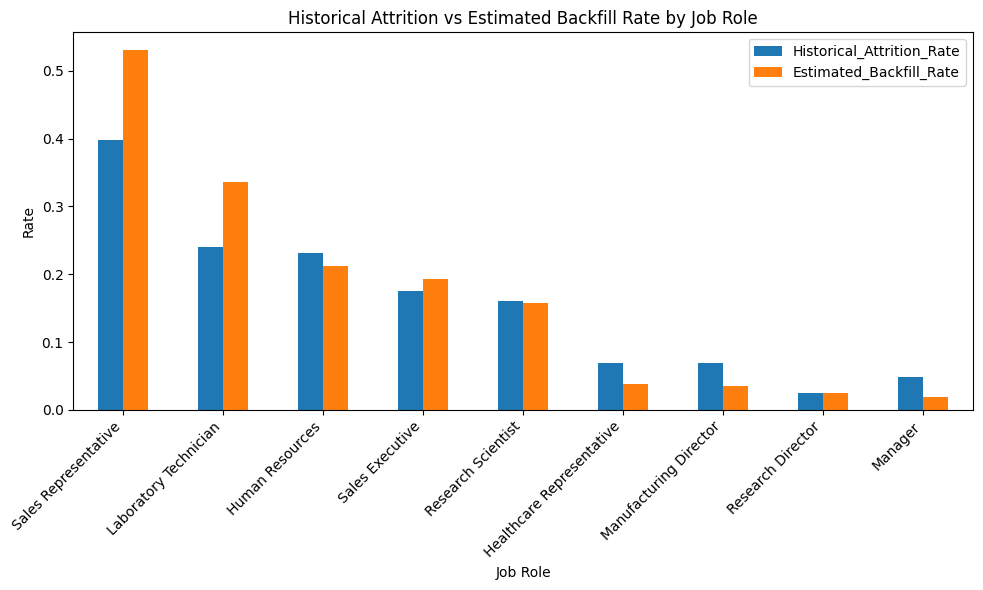

In [45]:
role_comparison[["Historical_Attrition_Rate", "Estimated_Backfill_Rate"]].sort_values(
    "Estimated_Backfill_Rate", ascending=False
).plot(kind="bar")

plt.title("Historical Attrition vs Estimated Backfill Rate by Job Role")
plt.ylabel("Rate")
plt.xlabel("Job Role")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Key Findings

### 1. Department-Level Attrition Risk
Sales and Human Resources show higher historical attrition rates than Research & Development. However, Research & Development is expected to generate the highest absolute replacement hiring demand because of its larger workforce size.

### 2. Overtime as a Strong Attrition Signal
Employees working overtime show substantially higher attrition rates than employees who do not work overtime, suggesting that workload and employee strain may be important retention risks.

### 3. High-Risk Job Roles
Sales Representatives, Laboratory Technicians, and Human Resources employees show the highest attrition pressure. These roles should be monitored closely in workforce planning.

### 4. Employee Experience Matters
Lower job satisfaction and poor work-life balance are associated with higher attrition. Employees who leave also tend to have shorter tenure on average.

### 5. Predictive Workforce Planning
The tuned Logistic Regression model suggests that replacement hiring demand is likely to remain concentrated in a small set of departments and job roles. The strongest priority roles include:
- Laboratory Technician
- Sales Executive
- Research Scientist
- Sales Representative

Based on the analysis, the following actions are recommended for Talent Acquisition and workforce planning teams:

1. Prioritize proactive recruiting pipelines for high-pressure roles such as Sales Representative, Laboratory Technician, and Sales Executive.

2. Monitor departments with elevated replacement pressure, especially Sales and Research & Development.

3. Incorporate overtime and employee experience indicators into retention monitoring, as these appear strongly linked to attrition risk.

4. Use attrition prediction outputs as an input for backfill planning, recruiter capacity planning, and role prioritization.

## Limitations

This dataset does not contain a true time variable, so the project does not produce a time-series forecast of attrition. Instead, predicted attrition risk is used as a proxy for future replacement hiring demand.

In addition, this is a fictional HR dataset, so the analysis is intended to demonstrate analytical methodology rather than provide real organizational forecasts.

## Conclusion

This project used employee attrition prediction as a proxy for future replacement hiring demand. The analysis identified high-risk departments, employee groups, and job roles, and translated those findings into actionable Talent Acquisition planning insights.

The final Logistic Regression model, with an adjusted classification threshold of 0.30, improved recall and made the model more suitable for workforce planning. The results suggest that replacement hiring demand is likely to be concentrated in specific functions, especially Sales and selected technical roles.

Overall, this project demonstrates how predictive analytics can support Talent Acquisition teams in prioritizing future hiring effort.

In [46]:
final_priority_roles = role_comparison[
    ["Historical_Attrition_Rate", "Predicted_Leavers", "Estimated_Backfill_Rate"]
].sort_values("Estimated_Backfill_Rate", ascending=False)

final_priority_roles.head(5)

,Historical_Attrition_Rate,Predicted_Leavers,Estimated_Backfill_Rate
JobRole,,,
Sales Representative,0.397590,44,0.530120
Laboratory Technician,0.239382,87,0.335907
Human Resources,0.230769,11,0.211538
Sales Executive,0.174847,63,0.193252
Research Scientist,0.160959,46,0.157534


## Final Model Comparison

Two models were compared in this project:

- Logistic Regression
- Random Forest

In addition, Logistic Regression was evaluated with a lower classification threshold of 0.30 to better support workforce planning.

The tuned Logistic Regression model was selected as the final model because it achieved the best balance of recall and F1 score for identifying employees at risk of attrition.

In [58]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (0.50)",
        "Logistic Regression (0.30)",
        "Random Forest (0.50)"
    ],
    "Accuracy": [0.8605, 0.8401, 0.8469],
    "Precision": [0.6154, 0.5000, 0.6250],
    "Recall": [0.3404, 0.5106, 0.1064],
    "F1": [0.4384, 0.5053, 0.1818],
    "ROC_AUC": [0.8115, 0.8115, 0.7832]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (0.50),0.8605,0.6154,0.3404,0.4384,0.8115
1,Logistic Regression (0.30),0.8401,0.5000,0.5106,0.5053,0.8115
2,Random Forest (0.50),0.8469,0.6250,0.1064,0.1818,0.7832


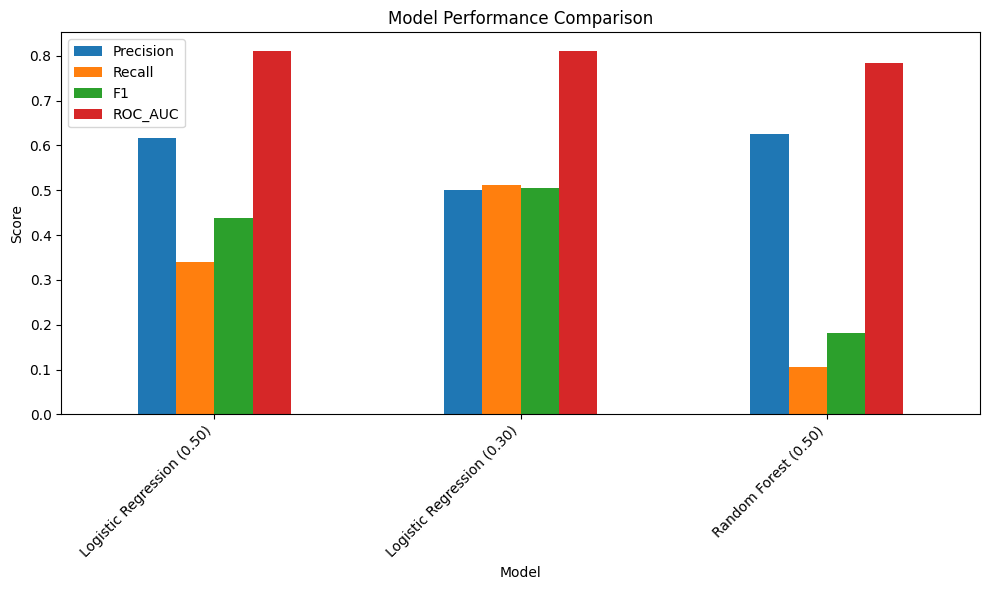

In [59]:
model_comparison.set_index("Model")[["Precision", "Recall", "F1", "ROC_AUC"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()